In [15]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler, StatevectorEstimator as Estimator
from qiskit_algorithms.optimizers import ADAM
from qiskit_machine_learning.algorithms import VQC
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN, EffectiveDimension, LocalEffectiveDimension, SamplerQNN

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_algorithms.optimizers import SPSA
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms.utils import algorithm_globals

# DATASETS

In [2]:
# datasets
SEED = 42

# changing it because it requires 4 inputs
X_class, y_class = make_classification(
    n_samples=200,
    n_features=4,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

# synthetic dataset
X_s = X_class
y_s = y_class
X_s_tr, X_s_test, y_s_tr, y_s_test = train_test_split(
    X_s,
    y_s,
    test_size=0.4,
    random_state=SEED
)

scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_s_tr = scaler.fit_transform(X_s_tr)
X_s_test = scaler.transform(X_s_test)


# this is already present in the full code - TO REMOVE
iris = load_iris(as_frame=True)

X = iris.data       
y = iris.target     

#taking two corresponding labels
mask = y < 2

X_set_vers = X[mask]
y_set_vers = y[mask]

#splitting in training and test
X_train_sv, X_test_sv, y_train_sv, y_test_sv = train_test_split(
    X_set_vers,
    y_set_vers,
    test_size=0.2,
    random_state=42
)

#scaling X datset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_sv = scaler.fit_transform(X_train_sv)
X_test_sv = scaler.transform(X_test_sv)


# binary dataset - setosa vs virginica
# already splitted and scaled above
X_b_tr = X_train_sv
X_b_test = X_test_sv
y_b_tr = y_train_sv
y_b_test = y_test_sv

X_b_tr = np.asarray(X_b_tr)
y_b_tr = np.asarray(y_b_tr)

X_b_test = np.asarray(X_b_test)
y_b_test = np.asarray(y_b_test)

# MODELS

In [17]:
'''
UPDATED VERSION OF THE CL MODEL WITH 60 PARAMETERS
'''

def build_model2(input_lenght=4, depth=2, n_class=2):

    model = Sequential()

    model.add(Dense(
        4,
        input_shape=(input_lenght,),
        activation='relu'
    ))

    for _ in range(depth - 1):

        model.add(Dense(
            4,
            activation='relu',
            use_bias=False
        ))

    model.add(Dense(
        n_class,
        activation='softmax',
        use_bias=False
    ))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# defining models
CL_model = build_model2(input_lenght=4, depth=3, n_class=2) 


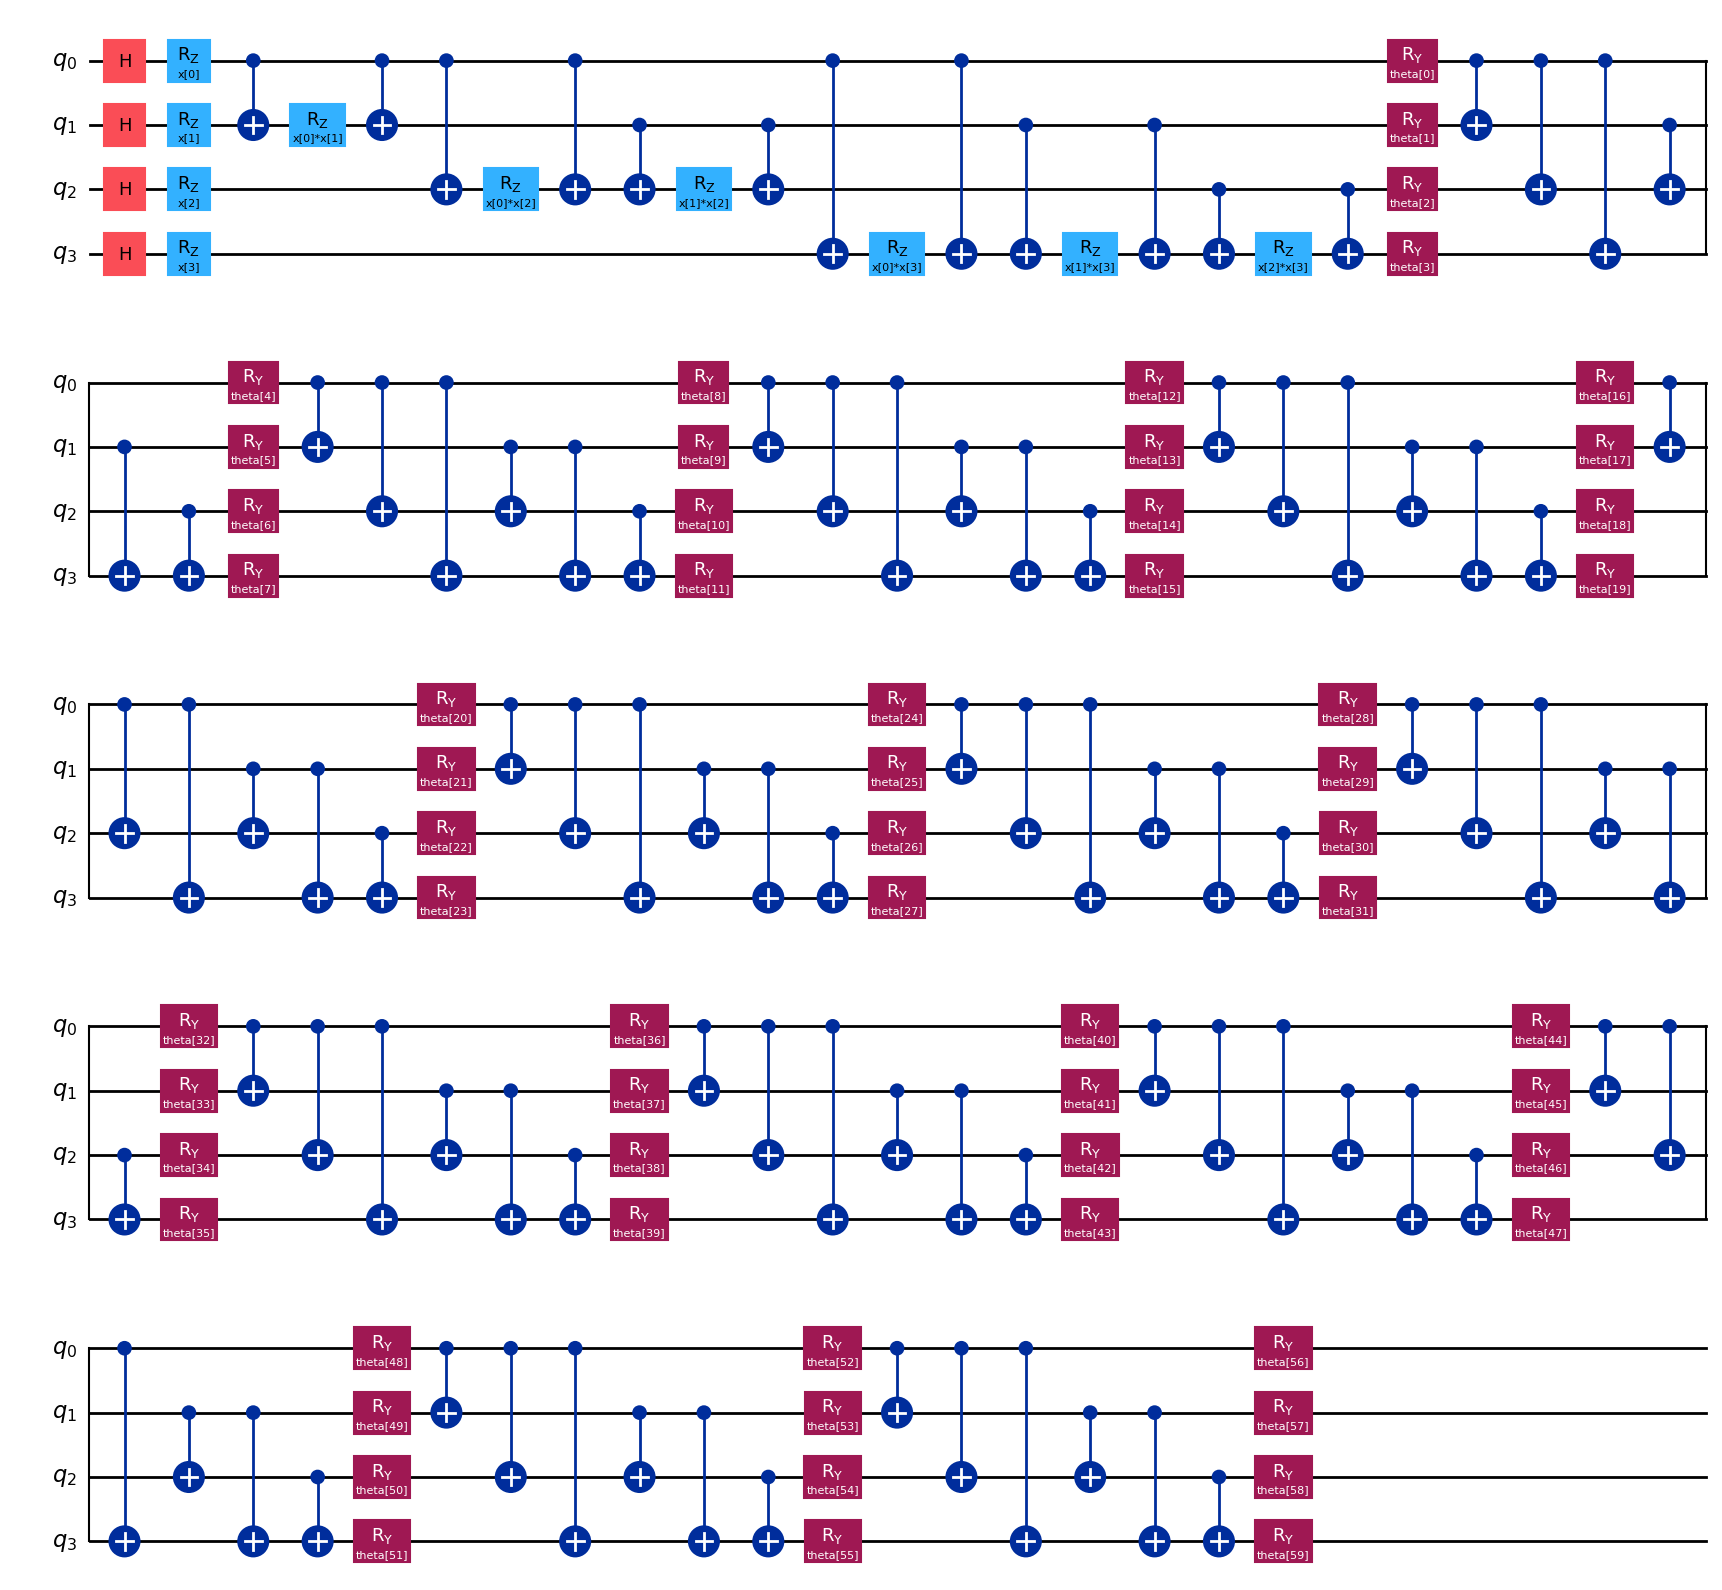

In [18]:
'''
QNN and EASY QNN with 60 parameters
'''

# -----------------------
# Feature Map without entanglement to provide a classical map into a quantum circuit
# -----------------------
def EasyFeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    qc.barrier()
    return qc

# -----------------------
# Feature Map
# -----------------------
def FeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    for i in range(N):
        for j in range(i):
            qc.cx(j, i)
            qc.rz(x[j] * x[i], i)
            qc.cx(j, i)
        qc.barrier()
    return qc



# to have a QNN with 60 trainable parameters

def Ansatz_60_par(n_bits):
    theta = ParameterVector('theta', 15*n_bits)
    qc = QuantumCircuit(n_bits)

    for l in range(14):
        for i in range(n_bits):
            qc.ry(theta[i+l*n_bits], i)
        qc.barrier()
    
        for i in range(n_bits-1):
            for j in range(i+1,N):
                qc.cx(i, j)
        qc.barrier()
        
    for i in range(n_bits):    
        qc.ry(theta[i+(l+1)*n_bits], i)
    qc.barrier()

    return qc


#-----------------------
# Parity Interpreter
# ----------------------
def parity(x):
    return "{:b}".format(x).count("1") % 2

def make_sampler_qnn(circ):
    x_p     = sorted([p for p in circ.parameters if p.name.startswith('x')],
                      key=lambda p: p.index)
    theta_p = sorted([p for p in circ.parameters if p.name.startswith('theta')],
                      key=lambda p: p.index)
    return SamplerQNN(
        circuit=circ,
        input_params=x_p,
        weight_params=theta_p,
        interpret=parity,
        output_shape=2,
        sampler=StatevectorSampler(),
    )

# defining models
N = 4
# Creating the Circuits' parts
easy_feature_map = EasyFeatureMap(N)
feature_map = FeatureMap(N)
ansatz      = Ansatz_60_par(N)


qc = feature_map.copy().compose(ansatz.copy())
qc.draw("mpl", style="iqp", plot_barriers=False)

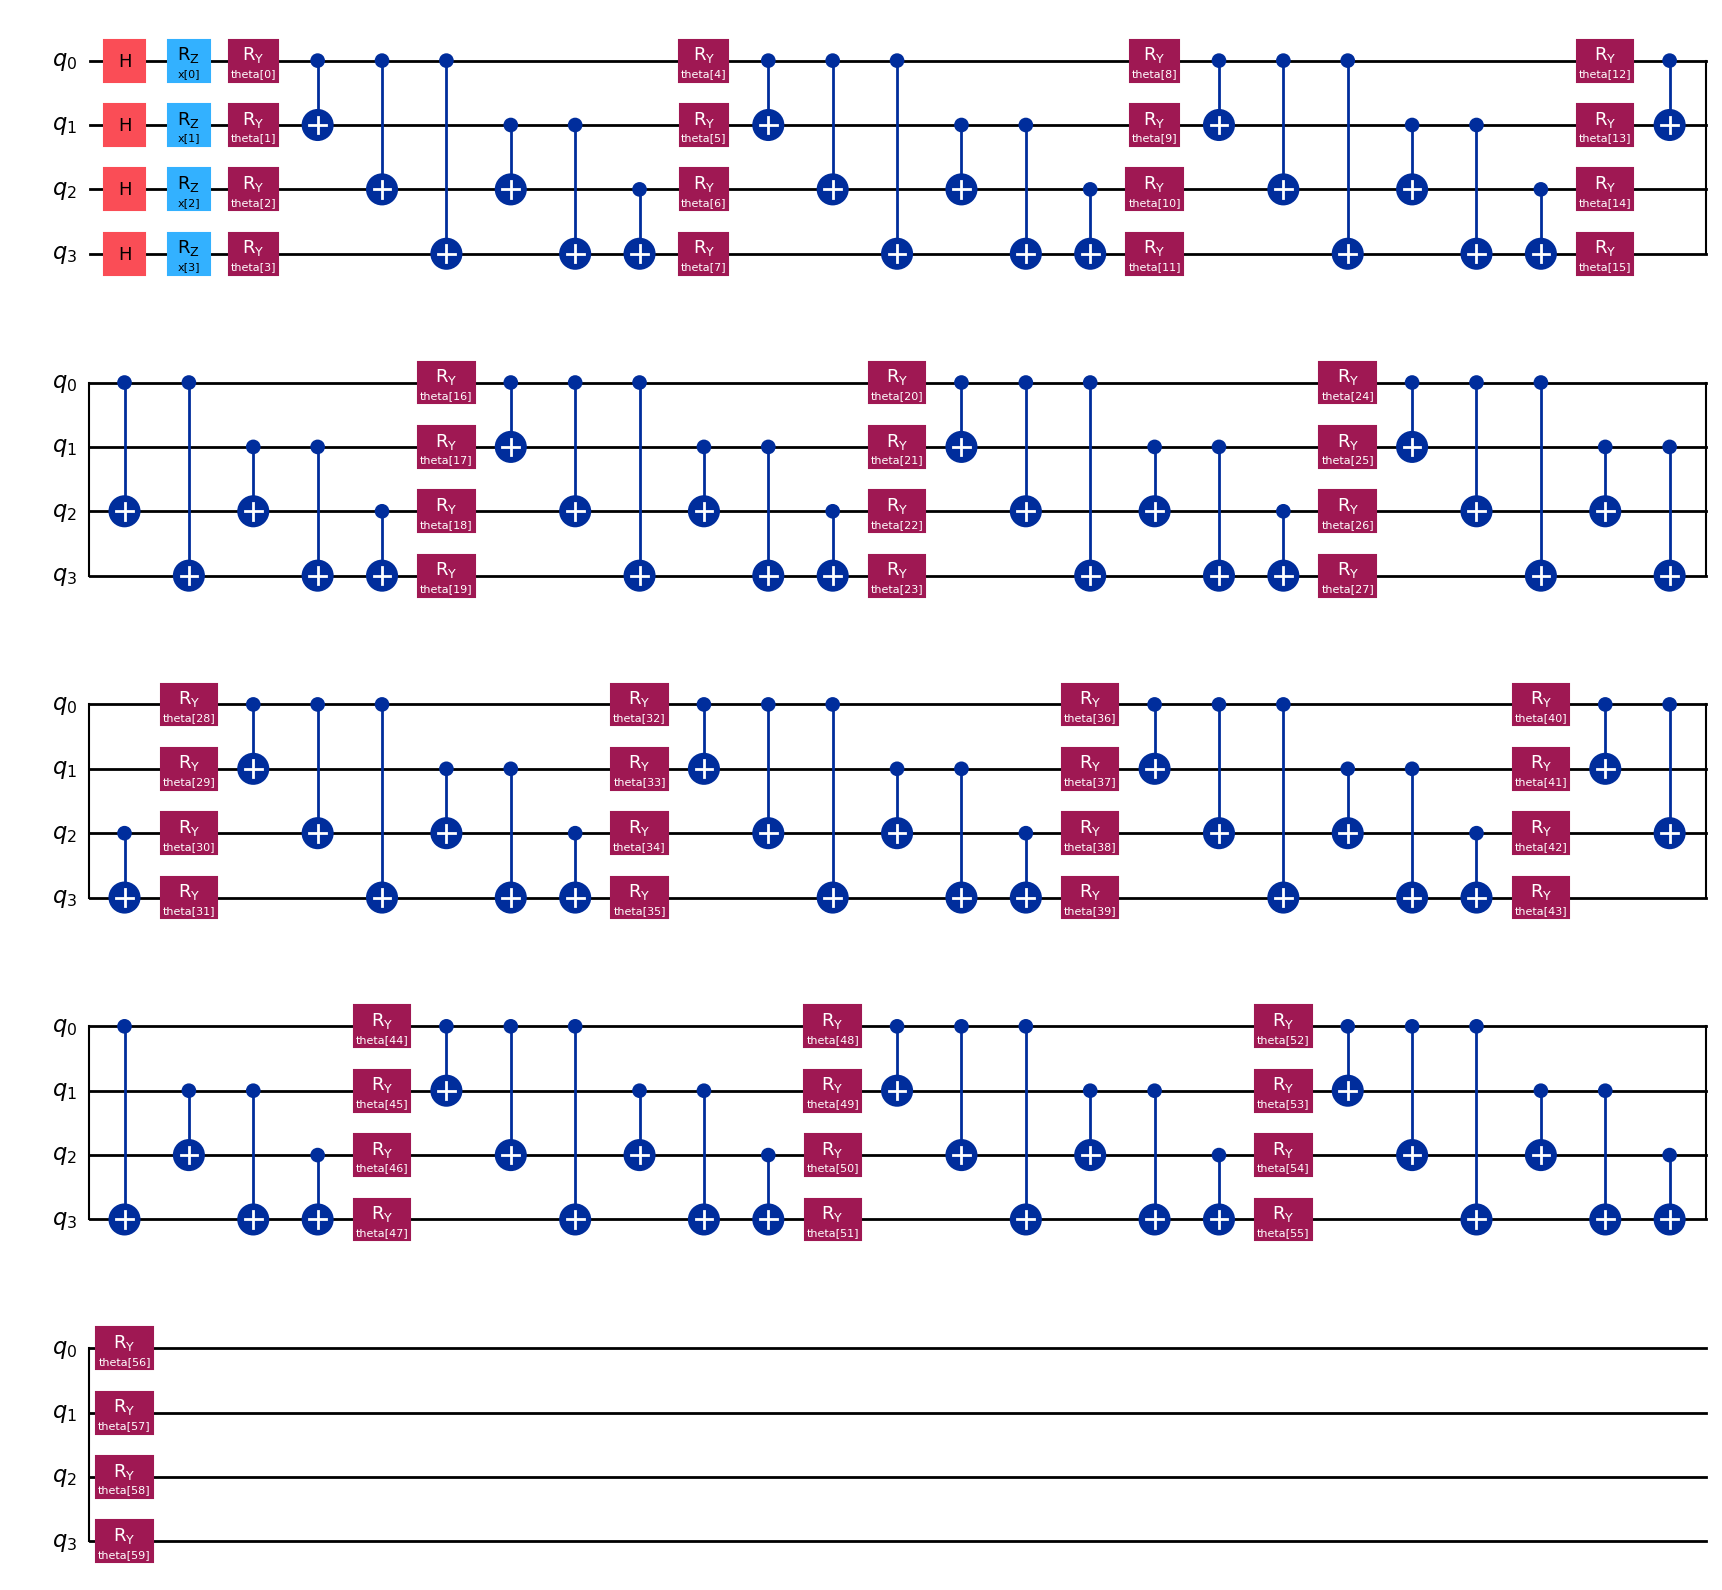

In [19]:
# defining models
# easy quantum model

qc_easy = easy_feature_map.copy().compose(ansatz.copy())
qc_easy.draw("mpl", style="iqp", plot_barriers=False)

# TRAINING LOSS AND TEST ACCURACY - SYNTHETIC DATASET

In [ ]:
# DO NOT RUN ANYMORE!!!!
# WE SAVE EVERYTHING IN SYNTHETIC/

EPOCHS     = 100
BATCH_SIZE = 16

n_runs = 5   
n_iter = 100


def make_adam_tracker(loss_list, weights_list=None, maxiter=100, N=4):
    log_n = np.log2(N)
    def adam_with_tracking(fun, x0, jac=None, **kwargs):
        optimizer = ADAM(maxiter=maxiter, lr=0.1, beta_1=0.9, beta_2=0.99, tol=1e-8)
        _cache = {'weights': None, 'loss': None}
        def cached_fun(weights):
            if _cache['weights'] is None or not np.array_equal(weights, _cache['weights']):
                _cache['weights'] = weights.copy()
                _cache['loss']    = fun(weights)
            return _cache['loss']
        def tracked_jac(weights):
            loss = cached_fun(weights)
            loss_list.append(float(loss) / log_n)
            if weights_list is not None:
                weights_list.append(weights.copy())
            return jac(weights)
        return optimizer.minimize(fun=cached_fun, x0=x0, jac=tracked_jac)
    return adam_with_tracking


def run_synthetic(seed):
    algorithm_globals.random_seed = seed
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

    q_loss  = []
    eq_loss = []
    q_weights  = []   
    eq_weights = []

    vqc = VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=make_adam_tracker(q_loss, q_weights),
        sampler=StatevectorSampler(),
    )
    e_vqc = VQC(
        feature_map=easy_feature_map,
        ansatz=ansatz,
        optimizer=make_adam_tracker(eq_loss, eq_weights),
        sampler=StatevectorSampler(),
    )
    CL_model = build_model2(input_lenght=4, depth=3, n_class=2)

    vqc.fit(X_s_tr, y_s_tr)
    e_vqc.fit(X_s_tr, y_s_tr)
    history = CL_model.fit(
        X_s_tr, y_s_tr,
        validation_data=(X_s_test, y_s_test),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        verbose=0, shuffle=True
    )

    q_acc = []
    for w in q_weights:
        preds = np.argmax(vqc.neural_network.forward(X_s_test, w), axis=1)
        q_acc.append(accuracy_score(y_s_test, preds))

    eq_acc = []
    for w in eq_weights:
        preds = np.argmax(e_vqc.neural_network.forward(X_s_test, w), axis=1)
        eq_acc.append(accuracy_score(y_s_test, preds))

    cl_loss = np.array(history.history['loss'])
    cl_acc  = np.array(history.history['val_accuracy'])

    return cl_loss, np.array(q_loss), np.array(eq_loss), cl_acc, np.array(q_acc), np.array(eq_acc)


for seed in range(n_runs):
    print(f'Running seed {seed}')
    cll, ql, eql, clacc, qacc, eqacc = run_synthetic(seed)

    with open(f"SYNTHETIC/cll_{seed}.pkl",  "wb") as f: pickle.dump(cll,  f)
    with open(f"SYNTHETIC/ql_{seed}.pkl", "wb") as f: pickle.dump(ql,   f)
    with open(f"SYNTHETIC/eql_{seed}.pkl",  "wb") as f: pickle.dump(eql,    f)
    with open(f"SYNTHETIC/clacc_{seed}.pkl",  "wb") as f: pickle.dump(clacc,    f)
    with open(f"SYNTHETIC/qacc_{seed}.pkl",  "wb") as f: pickle.dump(qacc,    f)
    with open(f"SYNTHETIC/equacc_{seed}.pkl",  "wb") as f: pickle.dump(eqacc,    f)

    # Non accumula nulla in RAM — scarta i risultati
    del cll, ql, eql, clacc, qacc, eqacc
    gc.collect()


In [20]:
# LOAD SYNTHETIC RUNS
EPOCHS     = 100
BATCH_SIZE = 16

n_runs = 5   # TO CHANGE
n_iter = 100

cl_all_losses = []
cl_all_accs   = []
q_all_losses  = []
q_all_accs    = []
eq_all_losses = []
eq_all_accs   = []

for seed in range(n_runs):
    with open(f"SYNTHETIC/cll_{seed}.pkl",  "rb") as f:    cl_all_losses.append(pickle.load(f))
    with open(f"SYNTHETIC/ql_{seed}.pkl", "rb") as f:      q_all_losses.append(pickle.load(f))
    with open(f"SYNTHETIC/eql_{seed}.pkl",  "rb") as f:    eq_all_losses.append(pickle.load(f))
    with open(f"SYNTHETIC/clacc_{seed}.pkl",  "rb") as f:  cl_all_accs.append(pickle.load(f))
    with open(f"SYNTHETIC/qacc_{seed}.pkl",  "rb") as f:   q_all_accs .append(pickle.load(f))
    with open(f"SYNTHETIC/equacc_{seed}.pkl",  "rb") as f: eq_all_accs.append(pickle.load(f))


cl_all_losses = np.array(cl_all_losses) # (n_run, n_iter)
cl_all_accs = np.array(cl_all_accs)
q_all_losses = np.array(q_all_losses)
q_all_accs = np.array(q_all_accs)
eq_all_losses = np.array(eq_all_losses)
eq_all_accs = np.array(eq_all_accs)


# mean and std
cl_loss_mean = cl_all_losses.mean(axis=0).ravel()
cl_loss_std = cl_all_losses.std(axis=0).ravel()
cl_accs_mean = cl_all_accs.mean(axis=0).ravel()
cl_accs_std = cl_all_accs.std(axis=0).ravel()

q_loss_mean = q_all_losses.mean(axis=0).ravel()
q_loss_std = q_all_losses.std(axis=0).ravel()
q_accs_mean = q_all_accs.mean(axis=0).ravel()
q_accs_std = q_all_accs.std(axis=0).ravel()

eq_loss_mean = eq_all_losses.mean(axis=0).ravel()
eq_loss_std = eq_all_losses.std(axis=0).ravel()
eq_accs_mean = eq_all_accs.mean(axis=0).ravel()
eq_accs_std = eq_all_accs.std(axis=0).ravel()


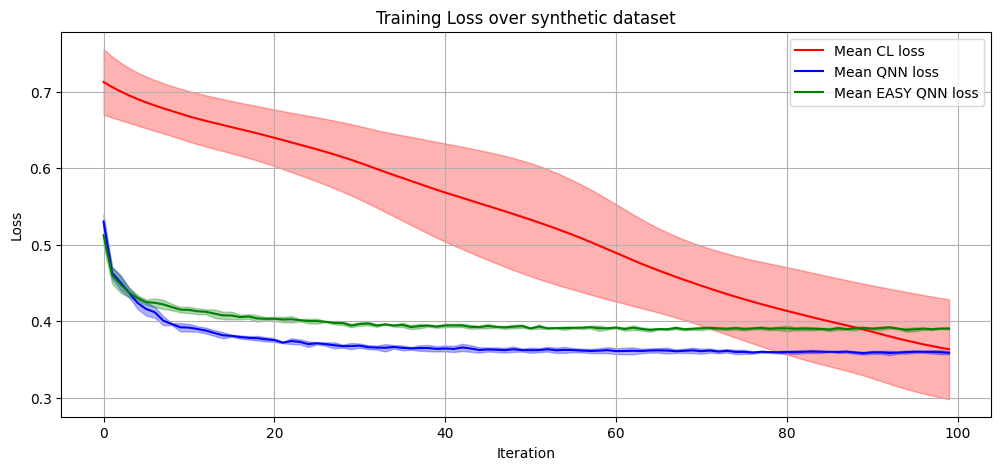

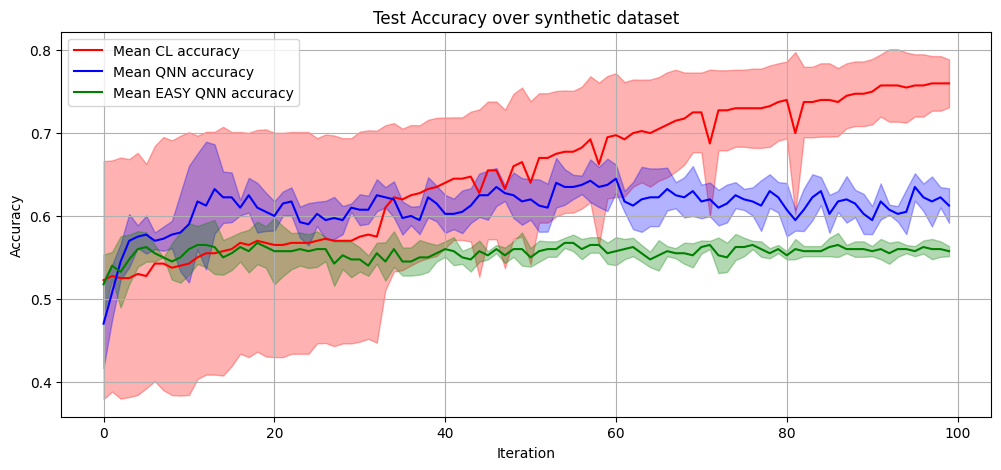

In [21]:
# plot loss
plt.figure(figsize=(12,5))

plt.plot(cl_loss_mean, label="Mean CL loss", c='r')
plt.fill_between(
    range(n_iter),
    cl_loss_mean - cl_loss_std,
    cl_loss_mean + cl_loss_std,
    color='r',
    alpha=0.3
)

plt.plot(q_loss_mean, label="Mean QNN loss", c='b')
plt.fill_between(
    range(n_iter),
    q_loss_mean - q_loss_std,
    q_loss_mean + q_loss_std,
    color='b',
    alpha=0.3
)

plt.plot(eq_loss_mean, label="Mean EASY QNN loss", c='g')
plt.fill_between(
    range(n_iter),
    eq_loss_mean - eq_loss_std,
    eq_loss_mean + eq_loss_std,
    color='g',
    alpha=0.3
)

plt.title("Training Loss over synthetic dataset")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.savefig("FIG_loss_syn.png")
plt.show()


# plot accuracy
plt.figure(figsize=(12,5))

plt.plot(cl_accs_mean, label="Mean CL accuracy", c='r')
plt.fill_between(
    range(n_iter),
    cl_accs_mean - cl_accs_std,
    cl_accs_mean + cl_accs_std,
    color='r',
    alpha=0.3
)

plt.plot(q_accs_mean, label="Mean QNN accuracy", c='b')
plt.fill_between(
    range(n_iter),
    q_accs_mean - q_accs_std,
    q_accs_mean + q_accs_std,
    color='b',
    alpha=0.3
)

plt.plot(eq_accs_mean, label="Mean EASY QNN accuracy", c='g')
plt.fill_between(
    range(n_iter),
    eq_accs_mean - eq_accs_std,
    eq_accs_mean + eq_accs_std,
    color='g',
    alpha=0.3
)

plt.title("Test Accuracy over synthetic dataset")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()
plt.savefig("FIG_acc_syn.png")
plt.show()

# TRAINING LOSS AND TEST ACCURACY - BINARY DATASET

In [ ]:
# DO NOT RUN ANYMORE!!!
# WE SAVE EVERYTHING IN BINARY/
n_runs = 5   # TO CHANGE
n_iter = 100



def run_binary(seed):
    algorithm_globals.random_seed = seed
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

    q_loss  = []
    eq_loss = []
    q_weights  = []
    eq_weights = []

    vqc = VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=make_adam_tracker(q_loss, q_weights),
        sampler=StatevectorSampler(),
    )
    e_vqc = VQC(
        feature_map=easy_feature_map,
        ansatz=ansatz,
        optimizer=make_adam_tracker(eq_loss, eq_weights),
        sampler=StatevectorSampler(),
    )
    CL_model = build_model2(input_lenght=4, depth=3, n_class=2)

    vqc.fit(X_b_tr, y_b_tr)
    e_vqc.fit(X_b_tr, y_b_tr)
    history = CL_model.fit(
        X_b_tr, y_b_tr,
        validation_data=(X_b_test, y_b_test),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        verbose=0, shuffle=True
    )

    q_acc = []
    for w in q_weights:
        preds = np.argmax(vqc.neural_network.forward(X_b_test, w), axis=1)
        q_acc.append(accuracy_score(y_b_test, preds))

    eq_acc = []
    for w in eq_weights:
        preds = np.argmax(e_vqc.neural_network.forward(X_b_test, w), axis=1)
        eq_acc.append(accuracy_score(y_b_test, preds))

    cl_loss = np.array(history.history['loss'])
    cl_acc  = np.array(history.history['val_accuracy'])

    return cl_loss, np.array(q_loss), np.array(eq_loss), cl_acc, np.array(q_acc), np.array(eq_acc)


for seed in range(n_runs):
    print(f'Running seed {seed}')
    cll, ql, eql, clacc, qacc, eqacc = run_binary(seed)

    with open(f"BINARY/cll_{seed}.pkl",  "wb") as f: pickle.dump(cll,  f)
    with open(f"BINARY/ql_{seed}.pkl", "wb") as f: pickle.dump(ql,   f)
    with open(f"BINARY/eql_{seed}.pkl",  "wb") as f: pickle.dump(eql,    f)
    with open(f"BINARY/clacc_{seed}.pkl",  "wb") as f: pickle.dump(clacc,    f)
    with open(f"BINARY/qacc_{seed}.pkl",  "wb") as f: pickle.dump(qacc,    f)
    with open(f"BINARY/equacc_{seed}.pkl",  "wb") as f: pickle.dump(eqacc,    f)


In [22]:
# LOAD BINARY RUNS
cl_all_losses = []
cl_all_accs   = []
q_all_losses  = []
q_all_accs    = []
eq_all_losses = []
eq_all_accs   = []

for seed in range(n_runs):
    with open(f"BINARY/cll_{seed}.pkl",  "rb") as f:    cl_all_losses.append(pickle.load(f))
    with open(f"BINARY/ql_{seed}.pkl", "rb") as f:      q_all_losses.append(pickle.load(f))
    with open(f"BINARY/eql_{seed}.pkl",  "rb") as f:    eq_all_losses.append(pickle.load(f))
    with open(f"BINARY/clacc_{seed}.pkl",  "rb") as f:  cl_all_accs.append(pickle.load(f))
    with open(f"BINARY/qacc_{seed}.pkl",  "rb") as f:   q_all_accs .append(pickle.load(f))
    with open(f"BINARY/equacc_{seed}.pkl",  "rb") as f: eq_all_accs.append(pickle.load(f))

cl_all_losses = np.array(cl_all_losses) # (n_run, n_iter)
cl_all_accs = np.array(cl_all_accs)
q_all_losses = np.array(q_all_losses)
q_all_accs = np.array(q_all_accs)
eq_all_losses = np.array(eq_all_losses)
eq_all_accs = np.array(eq_all_accs)


# mean and std
cl_loss_mean = cl_all_losses.mean(axis=0).ravel()
cl_loss_std = cl_all_losses.std(axis=0).ravel()
cl_accs_mean = cl_all_accs.mean(axis=0).ravel()
cl_accs_std = cl_all_accs.std(axis=0).ravel()

q_loss_mean = q_all_losses.mean(axis=0).ravel()
q_loss_std = q_all_losses.std(axis=0).ravel()
q_accs_mean = q_all_accs.mean(axis=0).ravel()
q_accs_std = q_all_accs.std(axis=0).ravel()

eq_loss_mean = eq_all_losses.mean(axis=0).ravel()
eq_loss_std = eq_all_losses.std(axis=0).ravel()
eq_accs_mean = eq_all_accs.mean(axis=0).ravel()
eq_accs_std = eq_all_accs.std(axis=0).ravel()


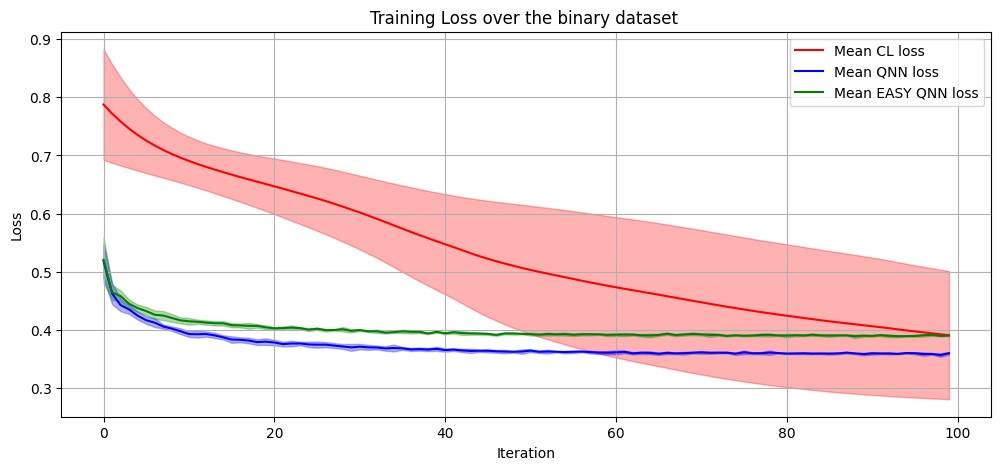

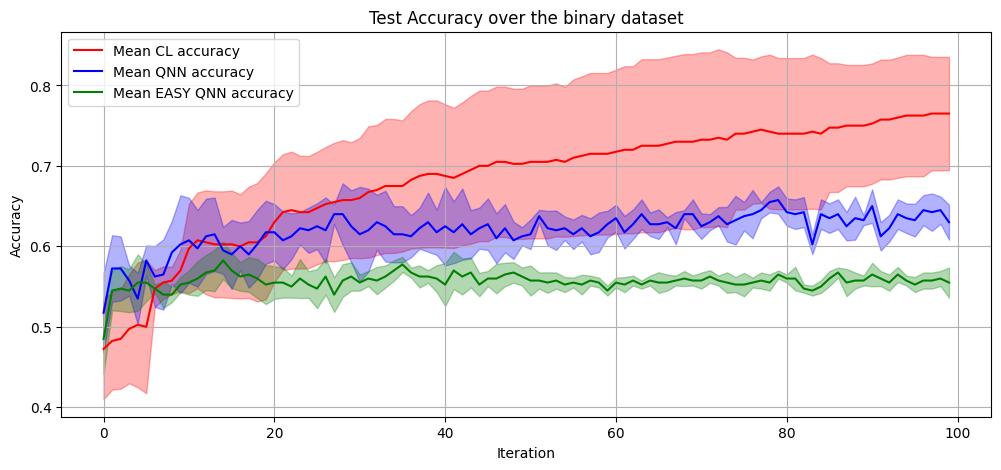

In [23]:
# plot loss
plt.figure(figsize=(12,5))

plt.plot(cl_loss_mean, label="Mean CL loss", c='r')
plt.fill_between(
    range(n_iter),
    cl_loss_mean - cl_loss_std,
    cl_loss_mean + cl_loss_std,
    color='r',
    alpha=0.3
)

plt.plot(q_loss_mean, label="Mean QNN loss", c='b')
plt.fill_between(
    range(n_iter),
    q_loss_mean - q_loss_std,
    q_loss_mean + q_loss_std,
    color='b',
    alpha=0.3
)

plt.plot(eq_loss_mean, label="Mean EASY QNN loss", c='g')
plt.fill_between(
    range(n_iter),
    eq_loss_mean - eq_loss_std,
    eq_loss_mean + eq_loss_std,
    color='g',
    alpha=0.3
)

plt.title("Training Loss over the binary dataset ")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.savefig("FIG_loss_bin.png")
plt.show()


# plot accuracy
plt.figure(figsize=(12,5))

plt.plot(cl_accs_mean, label="Mean CL accuracy", c='r')
plt.fill_between(
    range(n_iter),
    cl_accs_mean - cl_accs_std,
    cl_accs_mean + cl_accs_std,
    color='r',
    alpha=0.3
)

plt.plot(q_accs_mean, label="Mean QNN accuracy", c='b')
plt.fill_between(
    range(n_iter),
    q_accs_mean - q_accs_std,
    q_accs_mean + q_accs_std,
    color='b',
    alpha=0.3
)

plt.plot(eq_accs_mean, label="Mean EASY QNN accuracy", c='g')
plt.fill_between(
    range(n_iter),
    eq_accs_mean - eq_accs_std,
    eq_accs_mean + eq_accs_std,
    color='g',
    alpha=0.3
)

plt.title("Test Accuracy over the binary dataset")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()
plt.savefig("FIG_acc_bin.png")
plt.show()

# ED - SYNTHETIC DATASET

In [25]:
import pickle

algorithm_globals.random_seed = 42

# Dataset sizes to evaluate ED over (as in the official tutorial)
n = [1000, 3000, 5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]

N = 4

# create models
qnn_s = make_sampler_qnn(qc)
qnn_s_easy = make_sampler_qnn(qc_easy)
d = qnn_s.num_weights   
m = qnn_s.num_inputs 
print(f'num_inputs : {m}')
print(f'num_weights: {d}')

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


num_inputs : 4
num_weights: 60


In [8]:
# DONE
# ABOUT 14 HOURS

# 1. GLOBAL EFFECTIVE DIMENSION
# Calcultated over the whole space parameter

weights = np.random.uniform(-1, 1, size=(300,d)) # 300 to have enough weights (NOTE 16)


global_ed_qnn  = EffectiveDimension(qnn=qnn_s,      weight_samples=weights, input_samples=X_s_tr)
global_ed_easy = EffectiveDimension(qnn=qnn_s_easy, weight_samples=weights, input_samples=X_s_tr)



global_eff_qnn  = global_ed_qnn.get_effective_dimension(dataset_size=n)
print("DONE")
global_eff_easy = global_ed_easy.get_effective_dimension(dataset_size=n)

# save data
# Effective Dimension
with open("new_global_eff_qnn_syn.pkl", "wb") as f:
    pickle.dump(global_eff_qnn, f)
with open("new_global_eff_easy_syn.pkl", "wb") as f:
    pickle.dump(global_eff_easy, f)


'\n# 1. GLOBAL EFFECTIVE DIMENSION FOR QNN AND EASY QNN\n# Calcultated over the whole space parameter\n\n# in the standard EffectiveDimension():\n# parameters are sampled uniformly in [-1,1]\n# inputs are sampled from N[0,1]\n# I checked this in the GitHub repository\n\nweights = np.random.uniform(-1, 1, size=(300,d)) # 300 to have enough weights (NOTE 16)\ninputs = np.random.normal(0, 1, size=(100,m))\n\nglobal_ed_qnn  = EffectiveDimension(qnn=qnn_s,      weight_samples=weights, input_samples=inputs)\nglobal_ed_easy = EffectiveDimension(qnn=qnn_s_easy, weight_samples=weights, input_samples=inputs)\n\nglobal_eff_qnn  = global_ed_qnn.get_effective_dimension(dataset_size=n)\nglobal_eff_easy = global_ed_easy.get_effective_dimension(dataset_size=n)\n\n# save data\n# Effective Dimension\nwith open("global_eff_qnn_syn.pkl", "wb") as f:\n    pickle.dump(global_eff_qnn, f)\nwith open("global_eff_easy_syn.pkl", "wb") as f:\n    pickle.dump(global_eff_easy, f)\n'

In [8]:
# DONE
# ABOUT 6 HOURS

# 2. LOCAL EFFECTIVE DIMENSION FOR QNN AND EASY QNN
# calculated around the space parameter found after training the QNN/easy QNN

# Trained weights: run a quick VQC fit to get trained parameters
def get_trained_weights(feature_map_fn, ansatz_fn, N, x_tr, y_tr, maxiter=100):
    trained_weights_store = []
    def adam_capture(fun, x0, jac=None, **kwargs):
        opt = ADAM(maxiter=maxiter, lr=0.1, beta_1=0.9, beta_2=0.99, tol=1e-8)
        def tracked_jac(w):
            trained_weights_store.append(w.copy())
            return jac(w)
        return opt.minimize(fun=fun, x0=x0, jac=tracked_jac)
    vqc = VQC(
        sampler=StatevectorSampler(),
        feature_map=feature_map_fn(N),
        ansatz=ansatz_fn(N),
        optimizer=adam_capture,
    )
    vqc.fit(x_tr, y_tr)
    return trained_weights_store[-1] if trained_weights_store else vqc.weights

# Training QNNs for local ED
print('Training QNN for local ED...')
trained_weights_qnn  = get_trained_weights(FeatureMap, Ansatz_60_par, N, X_s_tr, y_s_tr)
print('Training easy QNN for local ED...')
trained_weights_easy = get_trained_weights(EasyFeatureMap, Ansatz_60_par, N, X_s_tr, y_s_tr)


local_ed_trained_qnn   = LocalEffectiveDimension(qnn=qnn_s,      weight_samples=trained_weights_qnn,  input_samples=X_s_tr)

local_ed_trained_easy   = LocalEffectiveDimension(qnn=qnn_s_easy, weight_samples=trained_weights_easy, input_samples=X_s_tr)

local_eff_trained_qnn    = local_ed_trained_qnn.get_effective_dimension(dataset_size=n)

local_eff_trained_easy   = local_ed_trained_easy.get_effective_dimension(dataset_size=n)


# save data
with open("object_local_ed_trained_qnn_syn.pkl", "wb") as f:
    pickle.dump(local_ed_trained_qnn, f)

with open("object_local_ed_trained_easy_syn.pkl", "wb") as f:
    pickle.dump(local_ed_trained_easy, f)

with open("local_eff_trained_qnn_syn.pkl", "wb") as f:
    pickle.dump(local_eff_trained_qnn, f)
with open("local_eff_trained_easy_syn.pkl", "wb") as f:
    pickle.dump(local_eff_trained_easy, f)
'''

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Training QNN for local ED...


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Training easy QNN for local ED...


In [26]:
# FUNCTIONS FOR CLASSICAL GLOBAL AND LOCAL ED

def get_shapes_sizes(model):
    ws = model.get_weights()
    shapes = [w.shape for w in ws]
    sizes = [w.size for w in ws]
    return shapes, sizes

def set_flat_weights(model, flat, shapes, sizes):
    new_weights = []
    idx = 0
    for shape, size in zip(shapes, sizes):
        new_weights.append(flat[idx:idx+size].reshape(shape).astype(np.float32))
        idx += size
    model.set_weights(new_weights)

# TRUE FISHER INFORMATION MATRIX - NOT EMPIRICAL
def compute_fisher_true(model, x_samples):
    """
    True Fisher Information Matrix for ONE set of weights,
    averaged over x_samples, using predicted class probabilities
    (not the true label y).
    """
    params = model.trainable_variables
    d = np.sum([tf.size(p).numpy() for p in params])

    F = np.zeros((d, d))
    N = len(x_samples)

    for x in x_samples:

        x = tf.convert_to_tensor([x], dtype=tf.float32)

        preds = model(x, training=False)[0]   # shape (num_classes,)
        num_classes = preds.shape[0]

        for c in range(num_classes):

            with tf.GradientTape() as tape:
                preds_c = model(x, training=False)[0]
                log_p_c = tf.math.log(preds_c[c] + 1e-12)

            grad = tape.gradient(log_p_c, params)

            # flatten gradients
            g = np.concatenate([
                tf.reshape(gr, [-1]).numpy()
                for gr in grad
            ])

            p_c = preds[c].numpy()
            F += p_c * np.outer(g, g)

    F /= N
    return F

    
def effective_dimension_local(F, n):
    """
    Local Effective Dimension — un solo set di pesi.
    Comparabile con LocalEffectiveDimension di Qiskit.
    """
    d = F.shape[0]
    kappa = n / (2 * np.pi * np.log(n))

    # Normalizzazione: F_hat = d * F / tr(F)
    F_hat = d * F / np.trace(F)

    I = np.eye(d)
    M = I + kappa * F_hat

    sign, logdet = np.linalg.slogdet(M)

    # Local ED: logdet / log(kappa)
    d_eff = logdet / np.log(kappa)
    
    return d_eff

def effective_dimension_global(fishers, n):
    """
    Global Effective Dimension — many weight samples (fishers is a list/array
    of Fisher matrices, one per theta). Comparable to Qiskit's EffectiveDimension.
    """
    d = fishers[0].shape[0]
    num_thetas = len(fishers)

    # average Fisher across all thetas, used only for the trace normalization
    F_avg = np.mean(fishers, axis=0)
    trace = np.trace(F_avg)

    kappa = n / (2 * np.pi * np.log(n))

    logdets = []
    for F in fishers:
        F_hat = d * F / trace
        M = np.eye(d) + kappa * F_hat
        sign, logdet = np.linalg.slogdet(M)
        logdets.append(0.5 * logdet)

    # logsumexp, done manually
    logdets = np.array(logdets)
    max_val = np.max(logdets)
    log_sum_exp = max_val + np.log(np.sum(np.exp(logdets - max_val)))

    d_eff = 2 * (log_sum_exp - np.log(num_thetas)) / np.log(kappa)
    return d_eff



In [27]:
# DONE 
# FAST

# LOCAL EFFECTIVE DIMENSION FOR THE CLASSICAL MODEL
import numpy as np
import tensorflow as tf
import pickle

EPOCHS = 100
BATCH_SIZE = 16

 
n = [1000, 3000, 5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]
eff_dim = []

model = build_model2(input_lenght=4, depth=3, n_class=2)

# training the model on the synthetic dataset
history = model.fit(
        X_s_tr, y_s_tr,
        validation_data=(X_s_test, y_s_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        shuffle=True
    )

# computing Fisher information
F_local = compute_fisher_true(model, X_s_tr)

# computing local ED for different dataset's sizes
local_ed = [effective_dimension_local(F_local, n_dat) for n_dat in n]

with open("local_eff_cl_syn.pkl", "wb") as f:
    pickle.dump(local_ed, f)

/home/laraf/jup-env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
# FISHER INFORMATION AND GLOBAL ED FOR CL

CL_model = build_model2(input_lenght=4, depth=3, n_class=2)
d = CL_model.count_params()   
m = 4

weights = np.random.uniform(-1, 1, size=(300, d))
inputs  = X_s_tr

fishers = []

for t in range(weights.shape[0]):
    set_flat_weights(CL_model, weights[t], *get_shapes_sizes(CL_model))  # reuse from earlier
    F_t = compute_fisher_true(CL_model, inputs)
    fishers.append(F_t)
    if t % 50 == 0:
        print(f"done {t}/{weights.shape[0]}")

n_list = [1000, 3000, 5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]

global_eff_cl_vs_n = [effective_dimension_global(fishers, n) for n in n_list]

for n, eff in zip(n_list, global_eff_cl_vs_n):
    print(f"n={n:>8}: Global ED CL = {eff:.4f}  normalized: {eff/d:.4f}")

with open("global_eff_cl_syn.pkl", "wb") as f:
    pickle.dump(global_eff_cl_vs_n, f)
    

done 0/300
done 50/300
done 100/300
done 150/300
done 200/300
done 250/300
n=    1000: Global ED CL = 28.8215  normalized: 0.4804
n=    3000: Global ED CL = 29.3048  normalized: 0.4884
n=    5000: Global ED CL = 29.7892  normalized: 0.4965
n=    8000: Global ED CL = 30.2998  normalized: 0.5050
n=   10000: Global ED CL = 30.5544  normalized: 0.5092
n=   40000: Global ED CL = 32.1786  normalized: 0.5363
n=   60000: Global ED CL = 32.6425  normalized: 0.5440
n=  100000: Global ED CL = 33.2088  normalized: 0.5535
n=  150000: Global ED CL = 33.6407  normalized: 0.5607
n=  200000: Global ED CL = 33.9365  normalized: 0.5656
n=  500000: Global ED CL = 34.8136  normalized: 0.5802
n= 1000000: Global ED CL = 35.4076  normalized: 0.5901


# Plots

<function matplotlib.pyplot.show(close=None, block=None)>

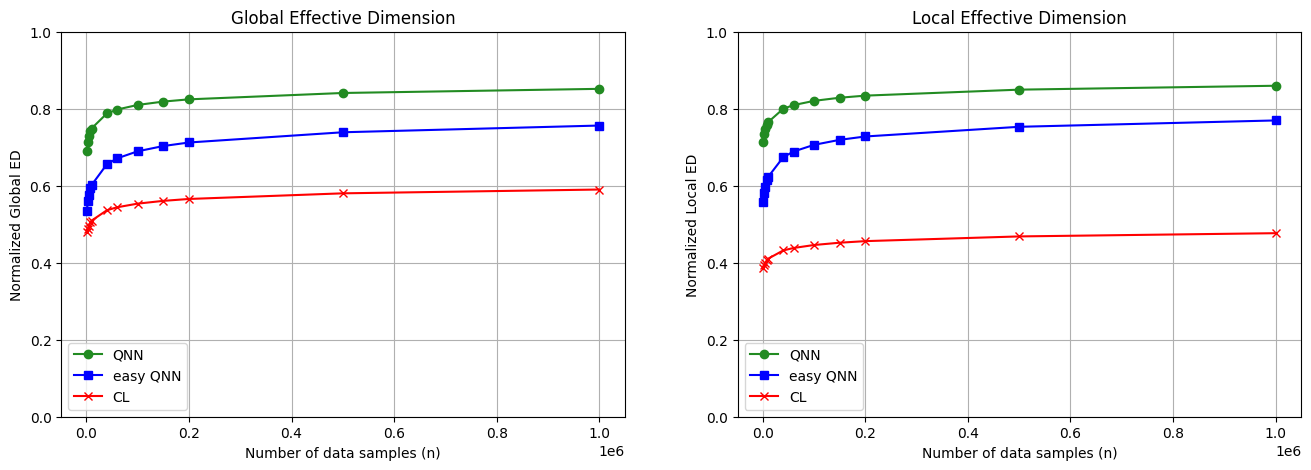

In [38]:
n = [1000, 3000, 5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]

global_eff_qnn = np.load('new_global_eff_qnn_syn.pkl', allow_pickle=True)
global_eff_easy = np.load('new_global_eff_easy_syn.pkl', allow_pickle=True)
global_eff_cl = np.load("global_eff_cl_syn.pkl", allow_pickle=True)
local_eff_trained_qnn = np.load('local_eff_trained_qnn_syn.pkl', allow_pickle=True)
local_eff_trained_easy = np.load('local_eff_trained_easy_syn.pkl', allow_pickle=True)
local_eff_CL = np.load('local_eff_cl_syn.pkl', allow_pickle=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Global ED
axes[0].plot(n, np.array(global_eff_qnn)  / d, marker='o', color='forestgreen',        label='QNN')
axes[0].plot(n, np.array(global_eff_easy) / d, marker='s', color='blue', label='easy QNN')
axes[0].plot(n, np.array(global_eff_cl) / d, marker='x', color='red', label='CL')
axes[0].set_ylim([0, 1])
axes[0].set_xlabel('Number of data samples (n)')
axes[0].set_ylabel('Normalized Global ED')
axes[0].set_title('Global Effective Dimension')
axes[0].legend()
axes[0].grid(True)


# Local ED
axes[1].plot(n, np.array(local_eff_trained_qnn)   / d, color='forestgreen', marker='o', label='QNN')
axes[1].plot(n, np.array(local_eff_trained_easy)   / d, color='blue', marker='s', label='easy QNN')
axes[1].plot(n, np.array(local_eff_CL)/d, color='red', marker='x', label='CL')
axes[1].set_ylim([0, 1])
axes[1].set_xlabel('Number of data samples (n)')
axes[1].set_ylabel('Normalized Local ED')
axes[1].set_title('Local Effective Dimension')
axes[1].legend()
axes[1].grid(True)
plt.savefig("GLOBAL VS LOCAL ED-SYN.png")
plt.show

# BINARY DATASET

In [31]:
import pickle

algorithm_globals.random_seed = 42

# Dataset sizes to evaluate ED over (as in the official tutorial)
n = [1000, 3000, 5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]

N = 4
qnn_s = make_sampler_qnn(qc)
qnn_s_easy = make_sampler_qnn(qc_easy)
d = qnn_s.num_weights   
m = qnn_s.num_inputs 
print(f'num_inputs : {m}')
print(f'num_weights: {d}')

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


num_inputs : 4
num_weights: 60


In [ ]:
# DONE

# 1. GLOBAL EFFECTIVE DIMENSION
# Calcultated over the whole space parameter

weights = np.random.uniform(-1, 1, size=(300,d))

global_ed_qnn  = EffectiveDimension(qnn=qnn_s,      weight_samples=weights, input_samples=X_b_tr)
global_ed_easy = EffectiveDimension(qnn=qnn_s_easy, weight_samples=weights, input_samples=X_b_tr)


global_eff_qnn  = global_ed_qnn.get_effective_dimension(dataset_size=n)
print("DONE")
global_eff_easy = global_ed_easy.get_effective_dimension(dataset_size=n)

# save data
# Effective Dimension
with open("new_global_eff_qnn_bin.pkl", "wb") as f:
    pickle.dump(global_eff_qnn, f)
with open("new_global_eff_easy_bin.pkl", "wb") as f:
    pickle.dump(global_eff_easy, f)


In [18]:
# ABOUT 6 HOURS

# 2. LOCAL EFFECTIVE DIMENSION
# calculated around the space parameter found after training the QNN/easy QNN (for trained)

# Trained weights: run a quick VQC fit to get trained parameters
def get_trained_weights(feature_map_fn, ansatz_fn, N, x_tr, y_tr, maxiter=100):
    trained_weights_store = []
    
    def adam_capture(fun, x0, jac=None, **kwargs):
        opt = ADAM(maxiter=maxiter, lr=0.1, beta_1=0.9, beta_2=0.99, tol=1e-8)
        def tracked_jac(w):
            trained_weights_store.append(w.copy())
            return jac(w)
            
        return opt.minimize(fun=fun, x0=x0, jac=tracked_jac)
        
    vqc = VQC(
        sampler=StatevectorSampler(),
        feature_map=feature_map_fn(N),
        ansatz=ansatz_fn(N),
        optimizer=adam_capture,
    )
    vqc.fit(x_tr, y_tr)
    
    return trained_weights_store[-1] if trained_weights_store else vqc.weights

# Training QNNs for local ED
print('Training QNN for local ED...')
trained_weights_qnn  = get_trained_weights(FeatureMap, Ansatz_60_par, N, X_b_tr, y_b_tr)
print('Training easy QNN for local ED...')
trained_weights_easy = get_trained_weights(EasyFeatureMap, Ansatz_60_par, N, X_b_tr, y_b_tr)


local_ed_trained_qnn   = LocalEffectiveDimension(qnn=qnn_s,      weight_samples=trained_weights_qnn,  input_samples=X_b_tr)

local_ed_trained_easy   = LocalEffectiveDimension(qnn=qnn_s_easy, weight_samples=trained_weights_easy, input_samples=X_b_tr)


local_eff_trained_qnn    = local_ed_trained_qnn.get_effective_dimension(dataset_size=n)

local_eff_trained_easy   = local_ed_trained_easy.get_effective_dimension(dataset_size=n)

with open("object_local_ed_trained_qnn_bin.pkl", "wb") as f:
    pickle.dump(local_ed_trained_qnn, f)

with open("object_local_ed_trained_easy_bin.pkl", "wb") as f:
    pickle.dump(local_ed_trained_easy, f)

with open("local_eff_trained_qnn_bin.pkl", "wb") as f:
    pickle.dump(local_eff_trained_qnn, f)
with open("local_eff_trained_easy_bin.pkl", "wb") as f:
    pickle.dump(local_eff_trained_easy, f)


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Training QNN for local ED...


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Training easy QNN for local ED...


In [33]:
# FAST
# LOCAL EFFECTIVE DIMENSION FOR THE CLASSICAL MODEL

EPOCHS = 100
BATCH_SIZE = 16

 
n = [1000, 3000, 5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]


model = build_model2(input_lenght=4, depth=3, n_class=2)

# training the model on the synthetic dataset
history = model.fit(
        X_b_tr, y_b_tr,
        validation_data=(X_b_test, y_b_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        shuffle=True
    )

# computing Fisher information
F_local = compute_fisher_true(model, X_b_tr) # CHANGE THIS

# computing local ED for different dataset's sizes
local_ed = [effective_dimension_local(F_local, n_dat) for n_dat in n]

with open("local_eff_cl_bin.pkl", "wb") as f:
    pickle.dump(local_ed, f)

/home/laraf/jup-env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
# GLOBAL ED FOR CLASSICAL MODEL

CL_model = build_model2(input_lenght=4, depth=3, n_class=2)
d = CL_model.count_params()   # 60
m = 4

weights = np.random.uniform(-1, 1, size=(300, d))
inputs  = np.random.normal(0, 1, size=(100, m))

fishers = []
for t in range(weights.shape[0]):
    set_flat_weights(CL_model, weights[t], *get_shapes_sizes(CL_model))  # reuse from earlier
    F_t = compute_fisher_true(CL_model, inputs)
    fishers.append(F_t)
    if t % 50 == 0:
        print(f"done {t}/{weights.shape[0]}")

n_list = [1000, 3000, 5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]

global_eff_cl_vs_n = [effective_dimension_global(fishers, n) for n in n_list]

for n, eff in zip(n_list, global_eff_cl_vs_n):
    print(f"n={n:>8}: Global ED CL = {eff:.4f}  normalized: {eff/d:.4f}")

with open("global_eff_cl_bin.pkl", "wb") as f:
    pickle.dump(global_eff_cl_vs_n, f)

done 0/300
done 50/300
done 100/300
done 150/300
done 200/300
done 250/300
n=    1000: Global ED CL = 26.1666  normalized: 0.4361
n=    3000: Global ED CL = 26.7292  normalized: 0.4455
n=    5000: Global ED CL = 27.1543  normalized: 0.4526
n=    8000: Global ED CL = 27.5813  normalized: 0.4597
n=   10000: Global ED CL = 27.7899  normalized: 0.4632
n=   40000: Global ED CL = 29.0890  normalized: 0.4848
n=   60000: Global ED CL = 29.4605  normalized: 0.4910
n=  100000: Global ED CL = 29.9278  normalized: 0.4988
n=  150000: Global ED CL = 30.3052  normalized: 0.5051
n=  200000: Global ED CL = 30.5796  normalized: 0.5097
n=  500000: Global ED CL = 31.4838  normalized: 0.5247
n= 1000000: Global ED CL = 32.1619  normalized: 0.5360


# PLOTS

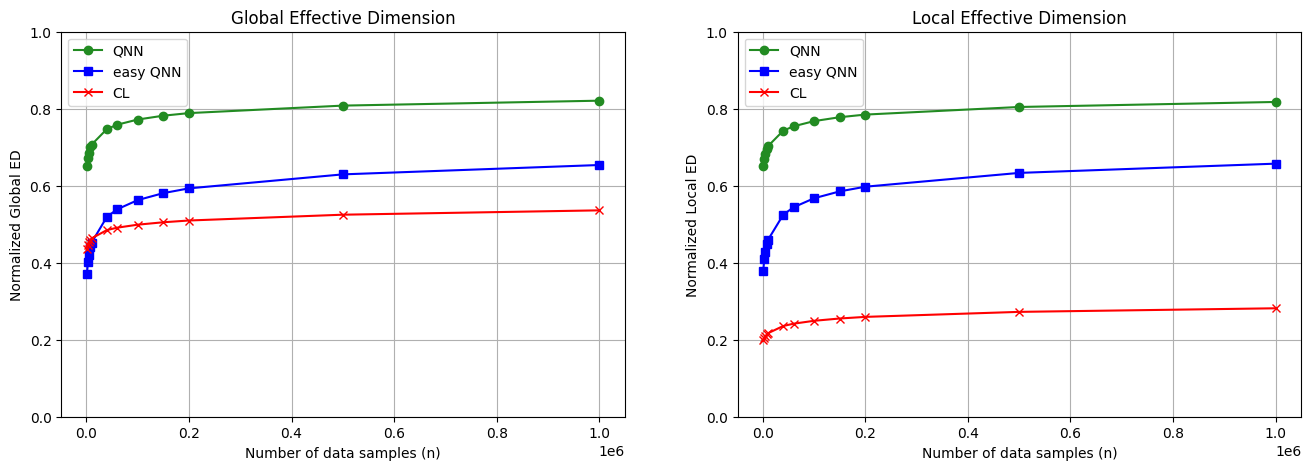

In [39]:
n = [1000, 3000, 5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]

global_eff_qnn = np.load('new_global_eff_qnn_bin.pkl', allow_pickle=True)
global_eff_easy = np.load('new_global_eff_easy_bin.pkl', allow_pickle=True)
global_eff_cl = np.load("global_eff_cl_bin.pkl", allow_pickle=True)
local_eff_trained_qnn = np.load('local_eff_trained_qnn_bin.pkl', allow_pickle=True)
local_eff_trained_easy = np.load('local_eff_trained_easy_bin.pkl', allow_pickle=True)
local_eff_CL = np.load('local_eff_cl_bin.pkl', allow_pickle=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Global ED
axes[0].plot(n, np.array(global_eff_qnn)  / d, marker='o', color='forestgreen',        label='QNN')
axes[0].plot(n, np.array(global_eff_easy) / d, marker='s', color='blue', label='easy QNN')
axes[0].plot(n, np.array(global_eff_cl) / d, marker='x', color='red', label='CL')
axes[0].set_ylim([0, 1])
axes[0].set_xlabel('Number of data samples (n)')
axes[0].set_ylabel('Normalized Global ED')
axes[0].set_title('Global Effective Dimension')
axes[0].legend()
axes[0].grid(True)

# Local ED
axes[1].plot(n, np.array(local_eff_trained_qnn)   / d, color='forestgreen', marker='o', label='QNN')
axes[1].plot(n, np.array(local_eff_trained_easy)   / d, color='blue', marker='s', label='easy QNN')
axes[1].plot(n, np.array(local_eff_CL)/d, color='red', marker='x', label='CL')
axes[1].set_ylim([0, 1])
axes[1].set_xlabel('Number of data samples (n)')
axes[1].set_ylabel('Normalized Local ED')
axes[1].set_title('Local Effective Dimension')
axes[1].legend()
axes[1].grid(True)
plt.savefig("GLOBAL VS LOCAL ED-BIN.png")
plt.show()

# GLOBAL VS LOCAL EFFECTIVE DIMENSION

# SYNTHETIC DATASET

In [41]:
global_eff_qnn = np.load('new_global_eff_qnn_syn.pkl', allow_pickle=True)
global_eff_easy = np.load('new_global_eff_easy_syn.pkl', allow_pickle=True)
global_eff_CL = np.load("global_eff_cl_syn.pkl", allow_pickle=True)
local_eff_trained_qnn = np.load('local_eff_trained_qnn_syn.pkl', allow_pickle=True)
local_eff_trained_easy = np.load('local_eff_trained_easy_syn.pkl', allow_pickle=True)
local_eff_CL = np.load('local_eff_cl_syn.pkl', allow_pickle=True)

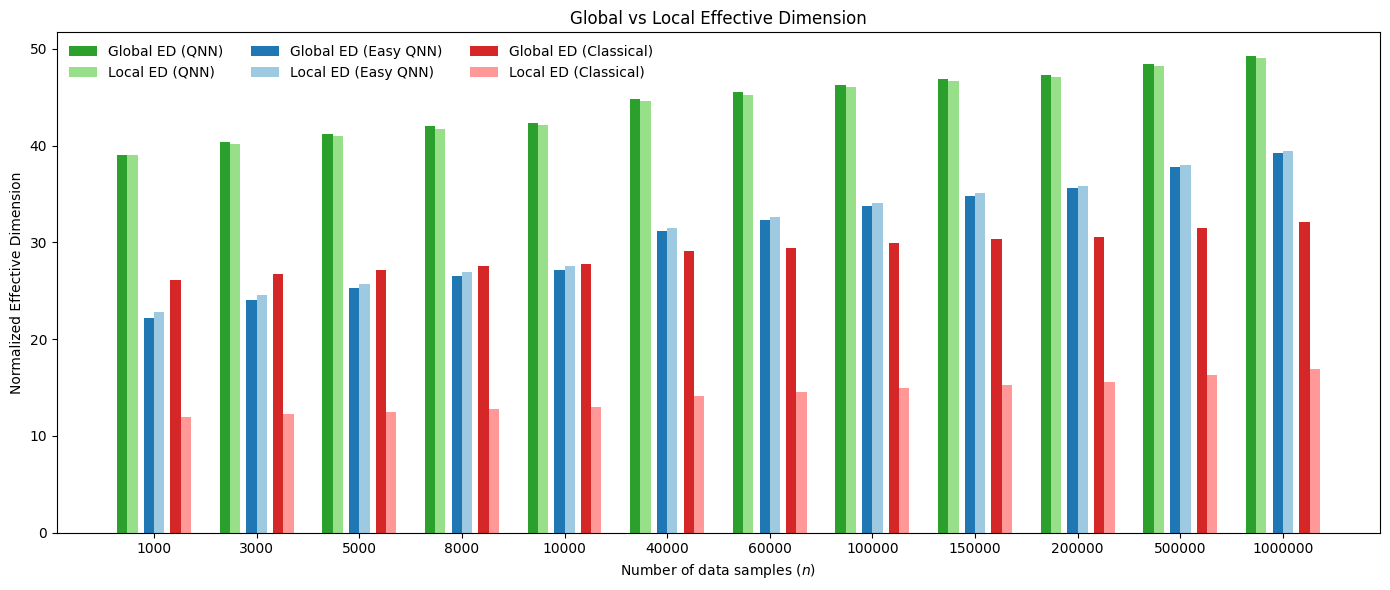

In [48]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(n))

w = 0.10          # bar width
gap = 0.06        # gap between model groups

qnn_center  = -2*w - gap
easy_center = 0
cl_center   =  2*w + gap

fig, ax = plt.subplots(figsize=(14, 6))

# QNN (green shades)
ax.bar(x + qnn_center - w/2, global_eff_qnn, w,
       color="#2ca02c", label="Global ED (QNN)") 
ax.bar(x + qnn_center + w/2, local_eff_trained_qnn, w,
       color="#98df8a", label="Local ED (QNN)")  

# Easy QNN (green shades)
ax.bar(x + easy_center - w/2, global_eff_easy, w,
       color="#1f77b4", label="Global ED (Easy QNN)")
ax.bar(x + easy_center + w/2, local_eff_trained_easy, w,
       color="#9ecae1", label="Local ED (Easy QNN)")

# Classical (red shades)
ax.bar(x + cl_center - w/2, global_eff_CL, w,
       color="#d62728", label="Global ED (Classical)")
ax.bar(x + cl_center + w/2, local_eff_CL, w,
       color="#ff9896", label="Local ED (Classical)")

ax.set_xticks(x)
ax.set_xticklabels(n)
ax.set_xlabel("Number of data samples ($n$)")
ax.set_ylabel("Normalized Effective Dimension")
ax.set_title("Global vs Local Effective Dimension")

ax.legend(ncol=3, frameon=False)

plt.tight_layout()
plt.savefig("ED - SYN.png")
plt.show()

# BINARY DATASET

In [46]:
global_eff_qnn = np.load('new_global_eff_qnn_bin.pkl', allow_pickle=True)
global_eff_easy = np.load('new_global_eff_easy_bin.pkl', allow_pickle=True)
global_eff_CL = np.load('global_eff_cl_bin.pkl', allow_pickle=True)
local_eff_trained_qnn = np.load('local_eff_trained_qnn_bin.pkl', allow_pickle=True)
local_eff_trained_easy = np.load('local_eff_trained_easy_bin.pkl', allow_pickle=True)
local_eff_CL = np.load('local_eff_cl_bin.pkl', allow_pickle=True)

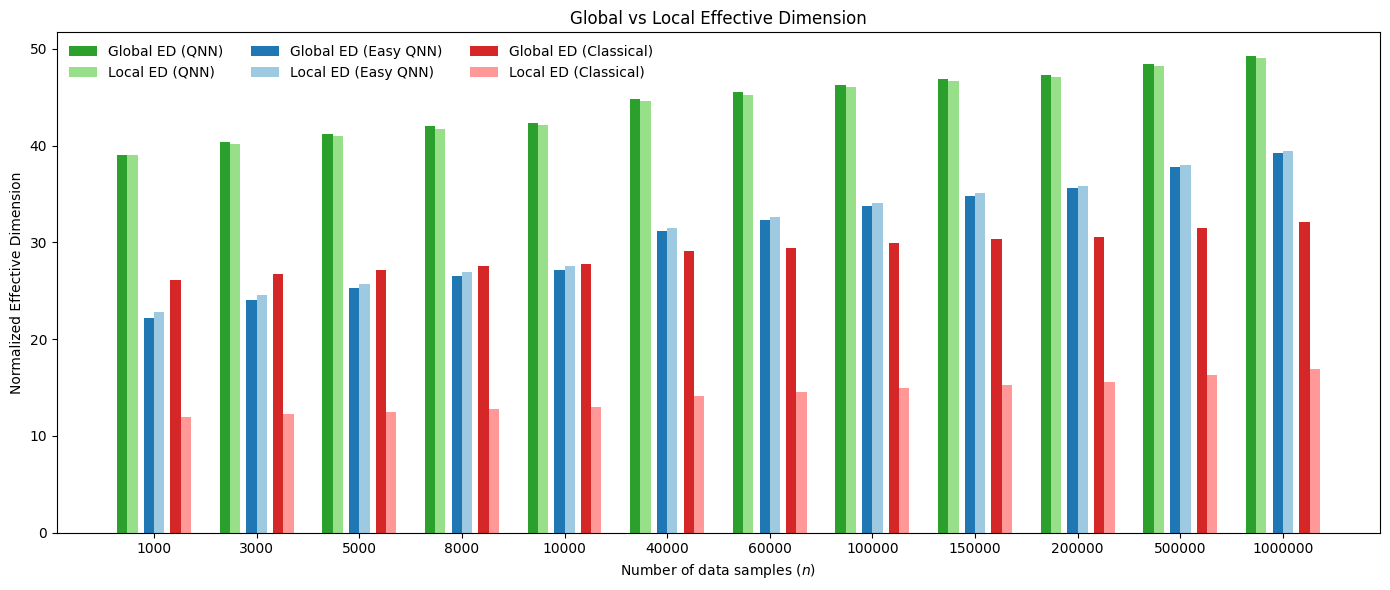

In [49]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(n))

w = 0.10          # bar width
gap = 0.06        # gap between model groups

qnn_center  = -2*w - gap
easy_center = 0
cl_center   =  2*w + gap

fig, ax = plt.subplots(figsize=(14, 6))

# QNN (green shades)
ax.bar(x + qnn_center - w/2, global_eff_qnn, w,
       color="#2ca02c", label="Global ED (QNN)") 
ax.bar(x + qnn_center + w/2, local_eff_trained_qnn, w,
       color="#98df8a", label="Local ED (QNN)")  

# Easy QNN (green shades)
ax.bar(x + easy_center - w/2, global_eff_easy, w,
       color="#1f77b4", label="Global ED (Easy QNN)")
ax.bar(x + easy_center + w/2, local_eff_trained_easy, w,
       color="#9ecae1", label="Local ED (Easy QNN)")

# Classical (red shades)
ax.bar(x + cl_center - w/2, global_eff_CL, w,
       color="#d62728", label="Global ED (Classical)")
ax.bar(x + cl_center + w/2, local_eff_CL, w,
       color="#ff9896", label="Local ED (Classical)")

ax.set_xticks(x)
ax.set_xticklabels(n)
ax.set_xlabel("Number of data samples ($n$)")
ax.set_ylabel("Normalized Effective Dimension")
ax.set_title("Global vs Local Effective Dimension")

ax.legend(ncol=3, frameon=False)

plt.tight_layout()
plt.savefig("ED - BIN.png")
plt.show()